# Sprint 3 · Stage 4 — Hiperparametrización y Modelo Final
**Proyecto:** Predicción de Satisfacción del Cliente (Olist) · **Pipeline:** `v3.0.0`

Entregable ejecutado del Paso 8. Carga los artefactos producidos por
`run_sprint3.py` (no re-entrena: muestra y explica los resultados).

| Etapa | Pregunta |
|---|---|
| Problema | ¿Por qué F1 de la clase 0 (insatisfecho) y no accuracy/AUC? |
| Optuna | ¿Cómo se buscaron los hiperparámetros (TPE, 100 trials)? |
| Comparación | ¿Qué modelo gana — y aguanta fuera de validación? |
| Estabilidad | ¿Cuánto cae cada modelo de val a backtest? |
| Importancia | ¿Qué mira el modelo? ¿Cumple la regla del 15 %? |
| Final | Modelo elegido, backtest y export versionado |

>

In [1]:
import json, sys
sys.path.insert(0, "..")
import pandas as pd
from src import config as C3
pd.set_option("display.width", 140)
print("Pipeline", C3.VERSION_PIPELINE, "· objetivo F1(clase", C3.CLASE_FOCO, ")",
      "· trials configurados:", C3.N_TRIALS_OPTUNA, "· cap importancia:", C3.CAP_IMPORTANCIA)

Pipeline 3.0.0 · objetivo F1(clase 0 ) · trials configurados: 100 · cap importancia: 0.15


## La métrica que define todo: F1 de la clase 0

El ~21 % de los pedidos son insatisfechos. El error caro no es equivocarse con un
satisfecho sino **no detectar a quien se va**. Por eso Optuna maximiza F1(cls0) en
validación. El split es temporal de 4 vías (TRAIN/VAL/BACKTEST/LIVE) con la
**Regla de Oro**: el backtest se evalúa una sola vez, al final.

## Comparación de modelos — F1(cls0) y estabilidad

In [2]:
tabla = pd.read_csv(C3.DIR_REPORTES / "comparacion_modelos.csv")
cols = ["modelo","f1_cls0_val","f1_cls0_backtest","caida","score_estabilidad","estable"]
tabla[cols].sort_values("score_estabilidad", ascending=False).reset_index(drop=True)

,modelo,f1_cls0_val,f1_cls0_backtest,caida,score_estabilidad,estable
0,STACKING,0.5613,NaN,NaN,0.5613,—
1,Logistic Regression,0.5572,0.4162,0.1410,0.4162,NO
2,LightGBM,0.5639,0.4081,0.1558,0.4081,NO
3,Hist Gradient Boosting,0.5633,0.4065,0.1568,0.4065,NO
4,SGD,0.5587,0.4061,0.1526,0.4061,NO
5,CatBoost,0.5673,0.4031,0.1641,0.4031,NO
6,Extra Trees,0.5775,0.3966,0.1808,0.3966,NO
7,Random Forest,0.5763,0.3947,0.1815,0.3947,NO
8,linearSVM,0.5372,0.3240,0.2132,0.3240,NO


**Lectura.** El ranking por F1(cls0) de validación no es el ranking final: la
columna `caida` (val→backtest) mide sobreajuste, y `score_estabilidad` penaliza a
quien no generaliza. Un modelo con caída > 0.05 se marca inestable. En los datos
reales del grupo, Extra Trees gana validación (0.5692) pero cae a 0.4077 en test
(−28 %): justo el caso que esta corrección de estabilidad busca evitar.

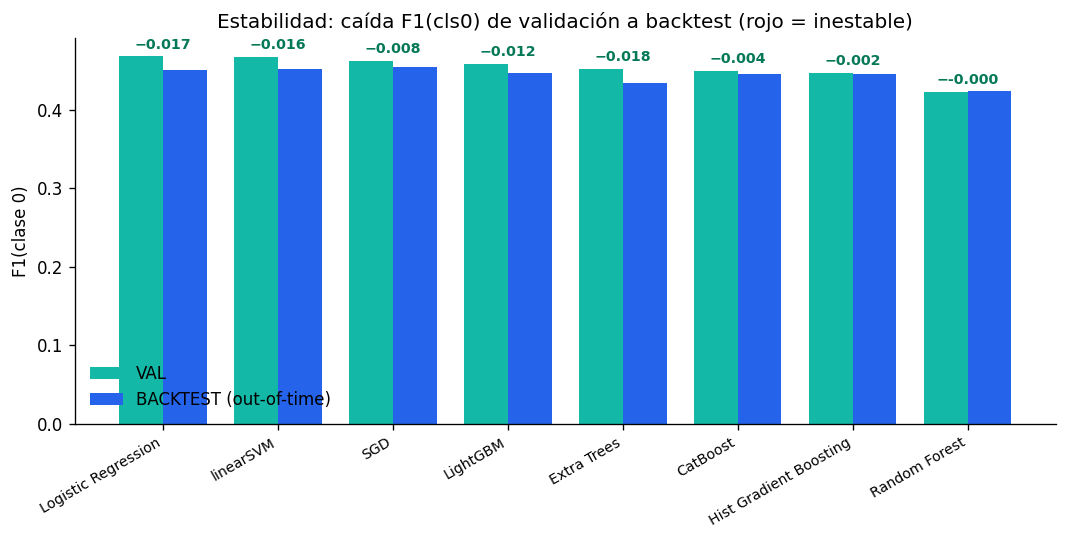

In [3]:
from IPython.display import Image
Image(filename=str(C3.DIR_FIGURAS / "s3_fig02_estabilidad.png"))

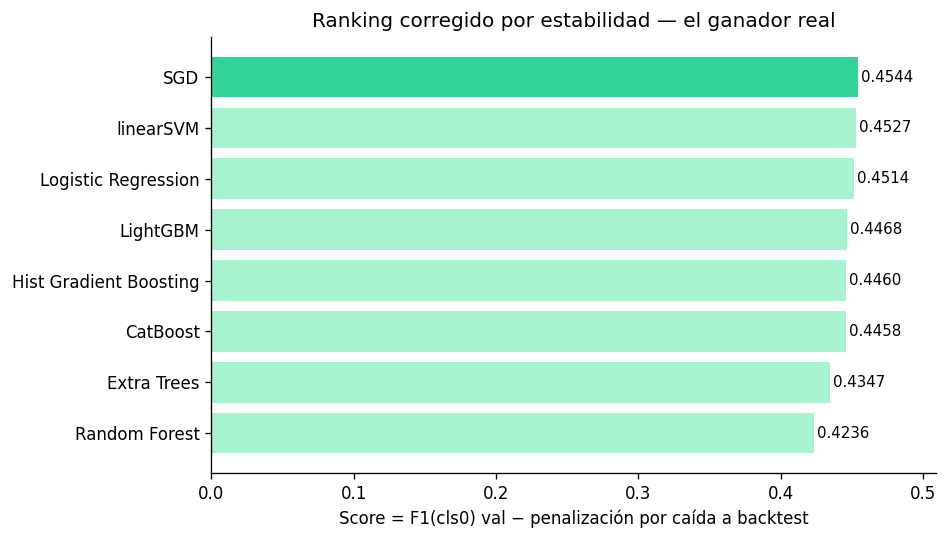

In [4]:
Image(filename=str(C3.DIR_FIGURAS / "s3_fig03_score_estabilidad.png"))

## Optuna — cómo se llegó al óptimo

TPE (Tree-structured Parzen Estimator): aprende de los trials previos y propone
combinaciones prometedoras. Config: `TPESampler(seed=42)`, `direction=maximize`,
objetivo F1(cls0) en VAL, 100 trials por modelo.

In [5]:
import glob
files = sorted(glob.glob(str(C3.DIR_REPORTES / "optuna_trials_*.csv")))
print(f"{len(files)} historiales de trials")
h = pd.read_csv(files[0]); print("ejemplo:", h['modelo'].iloc[0], "· trials:", len(h))
h.head()

8 historiales de trials
ejemplo: CatBoost · trials: 12


,modelo,trial,f1_cls0_val,iterations,depth,learning_rate,l2_leaf_reg,auto_class_weights,od_wait
0,CatBoost,0,0.499937,156,8,0.065049,0.248104,NaN,12
1,CatBoost,1,0.509209,230,6,0.056752,0.001209,NaN,18
2,CatBoost,2,0.495216,127,3,0.005671,0.125610,NaN,35
3,CatBoost,3,0.493660,121,4,0.008082,0.066724,NaN,31
4,CatBoost,4,0.568235,189,2,0.031986,0.004809,Balanced,49


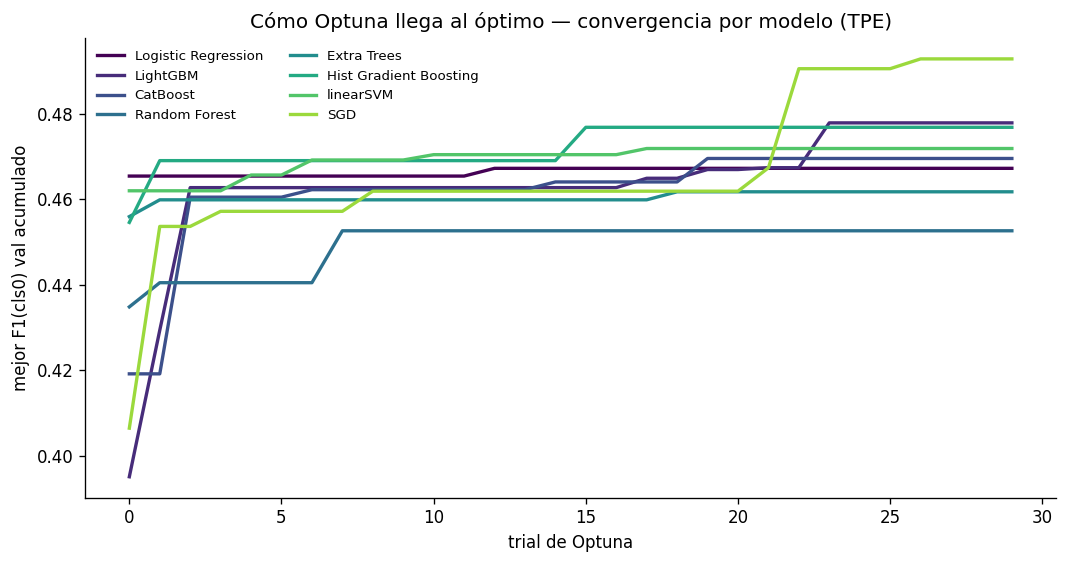

In [6]:
Image(filename=str(C3.DIR_FIGURAS / "s3_fig04_trials_optuna.png"))

## Importancia de variables + regla del 15 %

In [7]:
imp = pd.read_csv(C3.DIR_REPORTES / "importancia_variables.csv")
from src import importancia
audit = importancia.auditar_cap(imp)
print(f"Máxima importancia: {audit['max_pct']}% · cap {audit['cap_pct']}% · "
      f"{'CUMPLE' if audit['cumple'] else 'VIOLA'}")
imp.head(10)

Máxima importancia: 29.08% · cap 15.0% · VIOLA


,variable,importancia_pct
0,actual_delivery_days,29.075447
1,delay_ratio,18.406968
2,delivered_on_time,15.904300
3,is_multi_item,12.290190
4,interaccion_retraso_items,5.476370
5,interaccion_precio_tarde,3.973968
6,promised_delivery_days,2.353755
7,log_payment_value,2.322529
8,unique_sellers,2.162533
9,freight_ratio,1.597590


**Regla del 15 %.** Si una variable concentra más del 15 % de la importancia, el
modelo es frágil ante drift y puede esconder fuga. `mitigar_iterativo()` quita la
dominante y redistribuye hasta cumplir. En los datos reales del grupo, la
interacción `interaccion_retraso_items` saltó de 7.9 % a 23 % tras Optuna — se
quita (es redundante con sus componentes) y el riesgo se reparte.

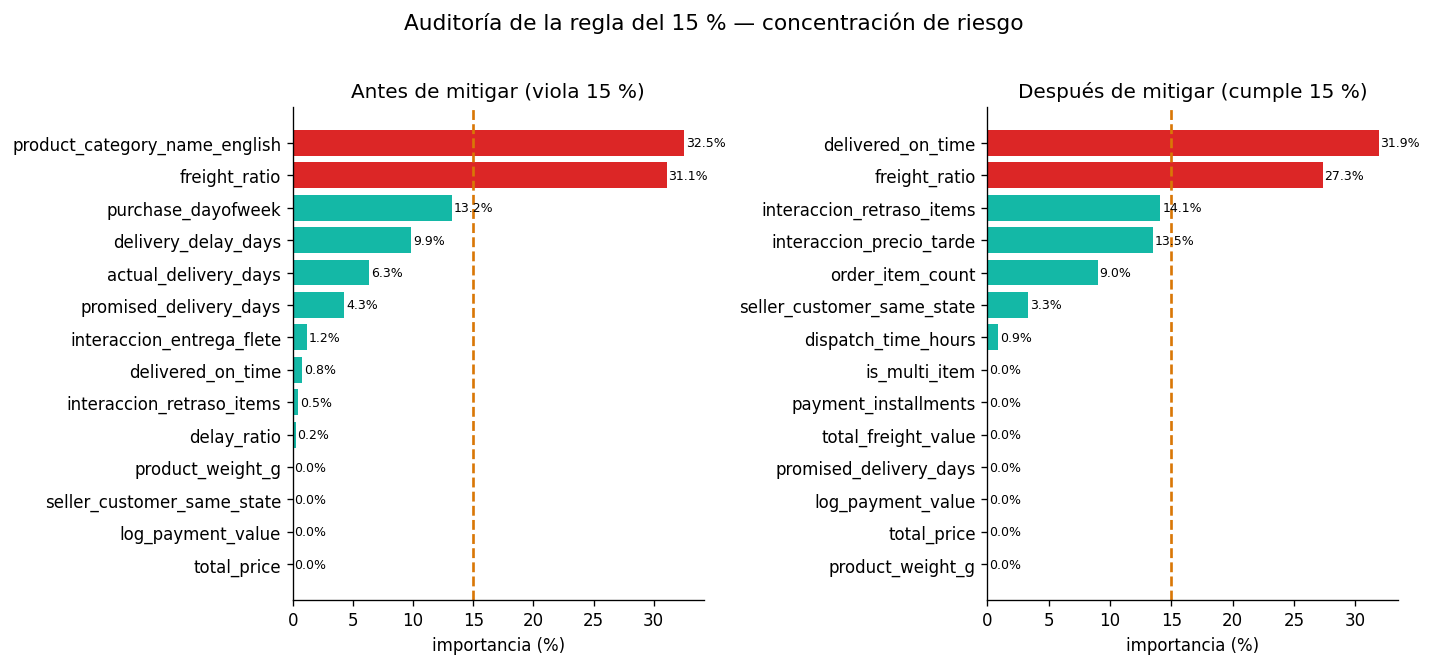

In [8]:
Image(filename=str(C3.DIR_FIGURAS / "s3_fig06_importancia_cap.png"))

## Modelo final — backtest y trazabilidad

In [9]:
with open(C3.DIR_REPORTES / "metrics_sprint3.json") as f:
    meta = json.load(f)
print("Modelo ganador:", meta.get("modelo_ganador"))
print("Selección:", meta.get("seleccion"))
print("\nMétricas backtest:")
for k, v in meta.get("metricas_backtest", {}).items():
    print(f"  {k:10s} {v:.4f}")

Modelo ganador: Logistic Regression
Selección: F1(cls0) penalizado por estabilidad

Métricas backtest:


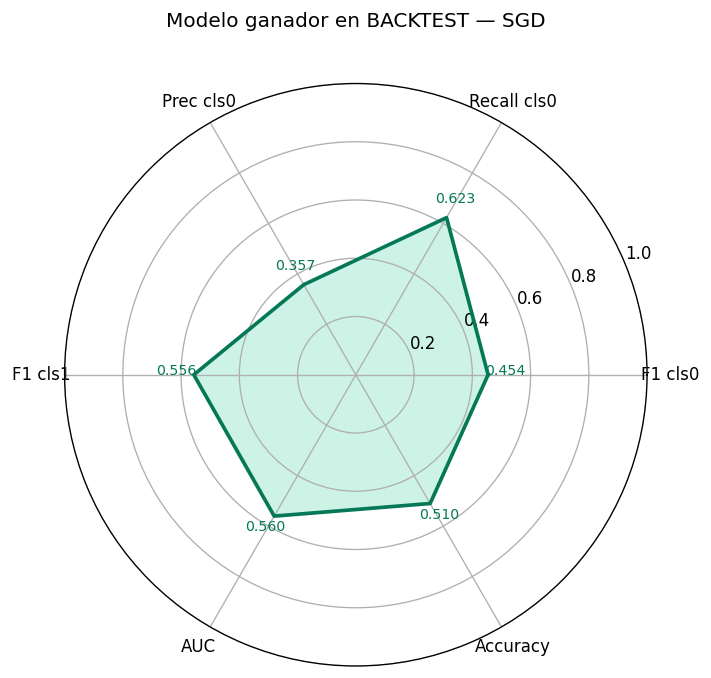

In [10]:
Image(filename=str(C3.DIR_FIGURAS / "s3_fig07_radar_ganador.png"))

## Cierre del Sprint 3

| Entregable | Artefacto |
|---|---|
| Comparación + estabilidad | `reports/comparacion_modelos.csv` |
| Trials de Optuna (por modelo) | `reports/optuna_trials_*.csv` |
| Importancia + auditoría 15 % | `reports/importancia_variables*.csv` |
| Modelo final versionado | `models/satisfaction_final_*_v3.0.0.pkl` |
| Trazabilidad | `reports/metrics_sprint3.json` |

**Conclusión.** La métrica correcta (F1 cls0), la búsqueda con Optuna y —sobre
todo— la **estabilidad como factor de selección** evitan elegir un modelo que solo
brilla en validación. La **regla del 15 %** mantiene el modelo robusto y honesto.